# Tukey-Lambda Distribution

The **Tukey-Lambda distribution** is a one-parameter family used primarily as a **diagnostic tool** — not for modelling per se, but for identifying which symmetric distribution best fits a dataset using PPCC plots. By scanning $\lambda$ values, you can determine whether your data has heavy, normal, or light tails.

| $\lambda$ value | Approximates |
|---|---|
| $\lambda = -1$ | Cauchy (very heavy tails) |
| $\lambda = 0$ | Logistic |
| $\lambda \approx 0.14$ | Normal |
| $\lambda = 0.5$ | U-shaped |
| $\lambda = 1$ | Uniform $(-1, 1)$ |

| Property | Value |
|---|---|
| **Parameter** | $\lambda$ (shape), $\mu$ (location), $\sigma$ (scale) |
| **PPF (only explicit formula)** | $G(p;\lambda) = \dfrac{p^\lambda - (1-p)^\lambda}{\lambda}$ |
| **PDF/CDF** | No closed form — computed from PPF numerically |
| **Symmetry** | Always symmetric — only models symmetric data |
| **Primary use** | PPCC plot — select best-fitting symmetric distribution |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

## Visualising the Tukey-Lambda Distribution

### Panel 1 — PDF: $\lambda$ Controls Tail Weight
Each curve shows the **Tukey-Lambda PDF** for key $\lambda$ values. Negative $\lambda$ gives very heavy tails (Cauchy-like); $\lambda=0$ is Logistic; $\lambda \approx 0.14$ matches Normal tails; $\lambda=1$ gives the Uniform distribution on a bounded interval.

### Panel 2 — PPF: $G(p) = (p^\lambda - (1-p)^\lambda)/\lambda$
The **percent-point function** (quantile function) is the only closed-form expression for the Tukey-Lambda family. Its shape directly reveals tail behaviour: steep at the extremes means heavy tails (large quantile spread); flat means light tails.

### Panel 3 — PPCC Scan
The **Probability Plot Correlation Coefficient (PPCC)** is computed for each $\lambda$ against a dataset. The $\lambda$ that maximises the Q-Q correlation identifies the best-fitting symmetric distribution — Normal data produces a peak near $\lambda=0.14$.


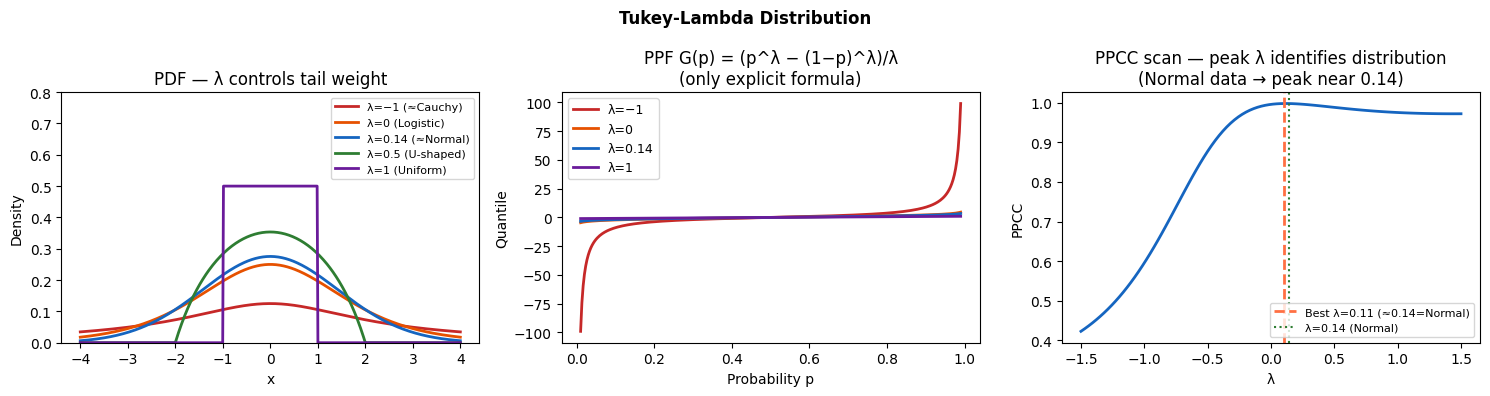

Best-fit λ = 0.106 (Normal expected: 0.14)


In [2]:
# scipy: stats.tukeylambda(lam)
x = np.linspace(-4, 4, 500)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Tukey-Lambda Distribution', fontsize=12, fontweight='bold')

# PDF for key lambda values
lambda_specs = [(-1,   '#C62828', 'λ=−1 (≈Cauchy)'),
                (0,    '#E65100', 'λ=0 (Logistic)'),
                (0.14, '#1565C0', 'λ=0.14 (≈Normal)'),
                (0.5,  '#2E7D32', 'λ=0.5 (U-shaped)'),
                (1,    '#6A1B9A', 'λ=1 (Uniform)')]
for lam, color, label in lambda_specs:
    try:
        y = stats.tukeylambda(lam).pdf(x)
        axes[0].plot(x, y, color=color, linewidth=2, label=label)
    except Exception:
        pass
axes[0].set_title('PDF — λ controls tail weight')
axes[0].set_xlabel('x'); axes[0].set_ylabel('Density')
axes[0].set_ylim(0, 0.8)
axes[0].legend(fontsize=8)

# PPF (only closed-form expression)
def tukey_ppf(p, lam):
    if abs(lam) < 1e-10:
        return np.log(p / (1-p))  # logistic
    return (p**lam - (1-p)**lam) / lam

p = np.linspace(0.01, 0.99, 300)
for lam, color, label in [(-1, '#C62828', 'λ=−1'), (0, '#E65100', 'λ=0'),
                            (0.14, '#1565C0', 'λ=0.14'), (1, '#6A1B9A', 'λ=1')]:
    axes[1].plot(p, tukey_ppf(p, lam), color=color, linewidth=2, label=label)
axes[1].set_title('PPF G(p) = (p^λ − (1−p)^λ)/λ\n(only explicit formula)')
axes[1].set_xlabel('Probability p'); axes[1].set_ylabel('Quantile')
axes[1].legend(fontsize=9)

# PPCC scan — find best λ for a dataset
np.random.seed(42)
data = stats.norm.rvs(size=200)
lambdas = np.linspace(-1.5, 1.5, 100)

def ppcc(data, lam):
    n = len(data)
    sorted_data = np.sort(data)
    p_vals = (np.arange(1, n+1) - 0.375) / (n + 0.25)
    theoretical = tukey_ppf(p_vals, lam)
    return np.corrcoef(sorted_data, theoretical)[0, 1]

correlations = [ppcc(data, lam) for lam in lambdas]
best_lam = lambdas[np.argmax(correlations)]

axes[2].plot(lambdas, correlations, color='#1565C0', linewidth=2)
axes[2].axvline(best_lam, color='#FF7043', linewidth=2, linestyle='--',
                label=f'Best λ={best_lam:.2f} (≈0.14=Normal)')
axes[2].axvline(0.14, color='#2E7D32', linewidth=1.5, linestyle=':',
                label='λ=0.14 (Normal)')
axes[2].set_title('PPCC scan — peak λ identifies distribution\n(Normal data → peak near 0.14)')
axes[2].set_xlabel('λ'); axes[2].set_ylabel('PPCC')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"Best-fit λ = {best_lam:.3f} (Normal expected: 0.14)")

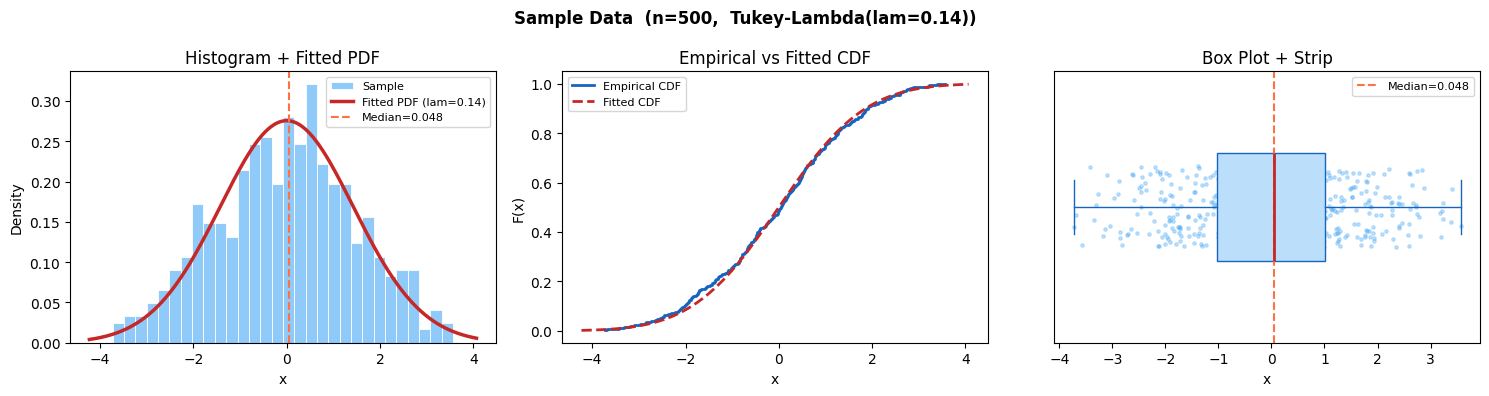

n=500  mean=-0.0184  median=0.0478  std=1.4959  skew=-0.0563  kurtosis=-0.4818


In [3]:
# Sample data plots — Tukey-Lambda(lam=0.14)
np.random.seed(42)
sample_d = stats.tukeylambda.rvs(0.14, size=500)
# Use fixed lam=0.14 directly (fitting tukeylambda can be unstable)
x_fit = np.linspace(sample_d.min() - 0.5, sample_d.max() + 0.5, 400)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Sample Data  (n=500,  Tukey-Lambda(lam=0.14))', fontsize=12, fontweight='bold')

# Histogram + fitted PDF
axes[0].hist(sample_d, bins=30, density=True,
             color='#90CAF9', edgecolor='white', linewidth=0.6, label='Sample')
axes[0].plot(x_fit, stats.tukeylambda(0.14).pdf(x_fit),
             color='#C62828', linewidth=2.5, label='Fitted PDF (lam=0.14)')
axes[0].axvline(np.median(sample_d), color='#FF7043', linewidth=1.5, linestyle='--',
                label=f'Median={np.median(sample_d):.3f}')
axes[0].set_title('Histogram + Fitted PDF')
axes[0].set_xlabel('x'); axes[0].set_ylabel('Density')
axes[0].legend(fontsize=8)

# Empirical vs fitted CDF
sorted_s = np.sort(sample_d)
ecdf = np.arange(1, len(sorted_s) + 1) / len(sorted_s)
axes[1].step(sorted_s, ecdf, color='#1565C0', linewidth=2, label='Empirical CDF')
axes[1].plot(x_fit, stats.tukeylambda(0.14).cdf(x_fit),
             color='#C62828', linewidth=2, linestyle='--', label='Fitted CDF')
axes[1].set_title('Empirical vs Fitted CDF')
axes[1].set_xlabel('x'); axes[1].set_ylabel('F(x)')
axes[1].legend(fontsize=8)

# Box plot + strip
axes[2].boxplot(sample_d, vert=False, patch_artist=True, widths=0.4,
                boxprops=dict(facecolor='#BBDEFB', color='#1565C0'),
                medianprops=dict(color='#C62828', linewidth=2),
                whiskerprops=dict(color='#1565C0'),
                capprops=dict(color='#1565C0'),
                flierprops=dict(marker='o', color='#FF7043', markersize=3, alpha=0.5))
axes[2].scatter(sample_d, np.random.uniform(0.85, 1.15, len(sample_d)),
                color='#42A5F5', s=6, alpha=0.3)
axes[2].axvline(np.median(sample_d), color='#FF7043', linewidth=1.5, linestyle='--',
                label=f'Median={np.median(sample_d):.3f}')
axes[2].set_title('Box Plot + Strip')
axes[2].set_xlabel('x'); axes[2].set_yticks([])
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()
print(f"n={len(sample_d)}  mean={sample_d.mean():.4f}  median={np.median(sample_d):.4f}  std={sample_d.std(ddof=1):.4f}  skew={stats.skew(sample_d):.4f}  kurtosis={stats.kurtosis(sample_d):.4f}")


## Key Takeaways

| | |
|---|---|
| **Diagnostic tool** | Primarily used for PPCC plots — not a modelling distribution |
| **$\lambda < 0.14$** | Heavy tails — Logistic ($\lambda=0$), Cauchy ($\lambda=-1$) |
| **$\lambda = 0.14$** | Normal tails |
| **$\lambda > 0.14$** | Light tails — Uniform ($\lambda=1$) |
| **PPCC scan** | Compute Q-Q correlation vs diagonal for each $\lambda$; peak = best fit |
| **Symmetric only** | Cannot diagnose skewed distributions — use Johnson system for asymmetric data |
| **PPF** | The only closed-form expression: $G(p) = (p^\lambda - (1-p)^\lambda)/\lambda$ |
